# Shear Center Calculation — S7055 Wing Section

This notebook calculates the shear-center location of the closed S7055 airfoil section using:

1. Thin-walled skin idealised as boom areas.
2. Added stringer/boom areas.
3. Final centroid of the idealised cross-section.
4. Centroidal second moments of area.
5. Basic shear flow due to a vertical shear force.
6. Constant redundant shear flow for a single-cell closed section.
7. Torque about the centroid.
8. Shear-center location.

The calculation uses the existing `week1_sd.py` and `week2a_sd.py` data conventions, but performs the shear-center calculation consistently about the **final centroid**.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rc('font', size=14)
np.set_printoptions(precision=5, suppress=True)

# ---------------------------------------------------------------------
# INPUTS
# ---------------------------------------------------------------------

airfoil_file = "s7055.dat"

# Wing / section data
chord = 0.265
skin_thickness = 0.5e-3

# Stringer geometry
stringer_thickness = 0.5e-3
stringer_length = 20e-3

# Number of stringers to add.
# Change this to match your section.
num_stringers = 7

# Stringer positions as normalized chordwise coordinates (x/c)
#
# Enter upper and lower stringer locations separately.
#
# Example:
# upper_stringer_x_norm = np.array([0.10, 0.30, 0.70, 0.90])
# lower_stringer_x_norm = np.array([0.10, 0.30, 0.70, 0.90])
#
# x/c = 0 -> Leading Edge
# x/c = 1 -> Trailing Edge

upper_stringer_x_norm = np.array([0.1, 0.3, 0.7, 0.9])
lower_stringer_x_norm = np.array([0.2,0.4,0.7])

# Vertical shear force used only to obtain the shear-center moment.
# The resulting shear-center location is independent of its magnitude.
V = 1.0  # N


In [18]:

# ---------------------------------------------------------------------
# LOAD AIRFOIL
# ---------------------------------------------------------------------

airfoil = np.loadtxt(airfoil_file) * chord

# Selig coordinates contain a duplicate trailing-edge point.
# Remove the final duplicate if it is coincident with the first point.
if np.allclose(airfoil[0], airfoil[-1]):
    airfoil = airfoil[:-1]

x = airfoil[:, 0]
y = airfoil[:, 1]

n = len(x)

# Closed panels
x_next = np.roll(x, -1)
y_next = np.roll(y, -1)

dx = x_next - x
dy = y_next - y
ds = np.hypot(dx, dy)

# Panel midpoints
x_mid = 0.5 * (x + x_next)
y_mid = 0.5 * (y + y_next)


In [19]:

# ---------------------------------------------------------------------
# 1. SKIN AREA IDEALISATION
# ---------------------------------------------------------------------

A_skin_panel = skin_thickness * ds
A_skin = np.sum(A_skin_panel)

x_centroid_skin = np.sum(A_skin_panel * x_mid) / A_skin
y_centroid_skin = np.sum(A_skin_panel * y_mid) / A_skin

print(f"Skin area       = {A_skin:.6e} m^2")
print(f"Skin centroid x = {x_centroid_skin:.6e} m")
print(f"Skin centroid y = {y_centroid_skin:.6e} m")

# ---------------------------------------------------------------------
# 2. BOOM AREAS
#
# Use the standard idealisation:
#
# B_i = t/6 * [
#       l_(i-1) (2 + y_(i-1)/y_i)
#     + l_i     (2 + y_(i+1)/y_i)
#     ]
#
# Here the boom formula is evaluated using the skin centroidal
# y-coordinate. The final centroid is then calculated from the
# complete idealised section.
#
# Points extremely close to the reference axis make this formula
# singular. For a robust shear-center calculation, use panel-area
# discretisation instead when such points occur.
# ---------------------------------------------------------------------

yc_skin = y - y_centroid_skin

# Check for points too close to the reference axis.
if np.any(np.abs(yc_skin) < 1e-10):
    raise ValueError(
        "A boom lies essentially on the skin centroidal axis. "
        "The standard boom-area formula becomes singular. "
        "Use a different boom/reference discretisation."
    )

l_prev = np.roll(ds, 1)
l_next = ds

y_prev = np.roll(yc_skin, 1)
y_next = np.roll(yc_skin, -1)

B_skin = (
    skin_thickness / 6.0
    * (
        l_prev * (2.0 + y_prev / yc_skin)
        + l_next * (2.0 + y_next / yc_skin)
    )
)


Skin area       = 2.695333e-04 m^2
Skin centroid x = 1.311096e-01 m
Skin centroid y = 6.145572e-03 m


In [20]:

# ---------------------------------------------------------------------
# 3. ADD STRINGER BOOM AREAS
# ---------------------------------------------------------------------

B_stringer = np.zeros(n)

# Stringer boom area
A_stringer = stringer_thickness * stringer_length


def find_surface_index(x_norm, surface):
    """
    Find the S7055 coordinate closest to the requested x/c
    on either the upper or lower surface.
    """

    x_target = x_norm * chord

    if surface == "upper":
        candidates = np.where(y >= 0)[0]
    elif surface == "lower":
        candidates = np.where(y <= 0)[0]
    else:
        raise ValueError("surface must be 'upper' or 'lower'")

    if len(candidates) == 0:
        raise ValueError(f"No points found on {surface} surface.")

    idx = candidates[np.argmin(np.abs(x[candidates] - x_target))]

    return idx


# -------------------------
# Upper stringers
# -------------------------

upper_stringer_indices = []

for x_norm in upper_stringer_x_norm:

    if not 0 <= x_norm <= 1:
        raise ValueError(
            f"Upper stringer x/c = {x_norm} is outside 0 <= x/c <= 1."
        )

    idx = find_surface_index(x_norm, "upper")

    B_stringer[idx] += A_stringer

    upper_stringer_indices.append(idx)


# -------------------------
# Lower stringers
# -------------------------

lower_stringer_indices = []

for x_norm in lower_stringer_x_norm:

    if not 0 <= x_norm <= 1:
        raise ValueError(
            f"Lower stringer x/c = {x_norm} is outside 0 <= x/c <= 1."
        )

    idx = find_surface_index(x_norm, "lower")

    B_stringer[idx] += A_stringer

    lower_stringer_indices.append(idx)


# Total boom area
B_total = B_skin + B_stringer


In [21]:

# ---------------------------------------------------------------------
# 4. FINAL CENTROID
# ---------------------------------------------------------------------

A_total = np.sum(B_total)

x_bar = np.sum(B_total * x) / A_total
y_bar = np.sum(B_total * y) / A_total

x_c = x - x_bar
y_c = y - y_bar

print()
print(f"Total idealised area = {A_total:.6e} m^2")
print(f"Final centroid x     = {x_bar:.6e} m")
print(f"Final centroid y     = {y_bar:.6e} m")

# ---------------------------------------------------------------------
# 5. SECOND MOMENTS OF AREA
# ---------------------------------------------------------------------

Ixx = np.sum(B_total * y_c**2)
Iyy = np.sum(B_total * x_c**2)
Ixy = np.sum(B_total * x_c * y_c)

D = Ixx * Iyy - Ixy**2

print()
print(f"Ixx = {Ixx:.6e} m^4")
print(f"Iyy = {Iyy:.6e} m^4")
print(f"Ixy = {Ixy:.6e} m^4")
print(f"D   = {D:.6e} m^8")



Total idealised area = 3.408985e-04 m^2
Final centroid x     = 1.292235e-01 m
Final centroid y     = 6.225905e-03 m

Ixx = 3.725397e-08 m^4
Iyy = 2.017989e-06 m^4
Ixy = -3.047830e-08 m^4
D   = 7.424917e-14 m^8


In [22]:

# ---------------------------------------------------------------------
# 6. BASIC SHEAR FLOW
#
# For a vertical shear force V:
#
# q_b = V/D * (Ixy*x - Ixx*y) integrated as a cumulative
# boom contribution.
#
# The first boom is taken as the cut/reference point.
#
# The panel flow is reconstructed by averaging adjacent nodal flows.
# ---------------------------------------------------------------------

# Contribution at each boom.
dq_b = (
    V / D
    * (
        Ixy * x_c
        - Ixx * y_c
    )
    * B_total
)

# Cumulative basic shear flow.
q_b = np.zeros(n)

for i in range(1, n):
    q_b[i] = q_b[i - 1] + dq_b[i - 1]


In [23]:

# ---------------------------------------------------------------------
# 7. REDUNDANT CONSTANT SHEAR FLOW
#
# For a single-cell closed section:
#
# integral(q ds) = 0
#
# Therefore:
#
# q0 = - integral(q_b ds) / integral(ds)
# ---------------------------------------------------------------------

q_b_panel = 0.5 * (q_b + np.roll(q_b, -1))

q0 = -np.sum(q_b_panel * ds) / np.sum(ds)

q_panel = q_b_panel + q0

print()
print(f"Basic-flow closure correction q0 = {q0:.6e} N/m")



Basic-flow closure correction q0 = 5.431646e-01 N/m


In [24]:

# ---------------------------------------------------------------------
# 8. TORQUE ABOUT THE FINAL CENTROID
#
# For each straight panel:
#
# dT = q * (x dy - y dx)
#
# For a straight panel:
#
# integral(x dy - y dx)
#     = x_i*y_(i+1) - y_i*x_(i+1)
# ---------------------------------------------------------------------

panel_moment_arm = (
    x_c * np.roll(y_c, -1)
    - y_c * np.roll(x_c, -1)
)

T_shear_flow = np.sum(q_panel * panel_moment_arm)

# Since V = 1 N:
x_sc = T_shear_flow / V

print()
print(f"Torque about centroid = {T_shear_flow:.6e} N m")
print(f"Shear-center x offset = {x_sc:.6e} m")
print(f"Shear-center x/c      = {x_sc / chord:.6f}")

# Absolute coordinate from LE
x_sc_LE = x_bar + x_sc

print(f"Shear-center x from LE = {x_sc_LE:.6e} m")
print(f"Shear-center x/c       = {x_sc_LE / chord:.6f}")



Torque about centroid = -4.644630e-03 N m
Shear-center x offset = -4.644630e-03 m
Shear-center x/c      = -0.017527
Shear-center x from LE = 1.245788e-01 m
Shear-center x/c       = 0.470109


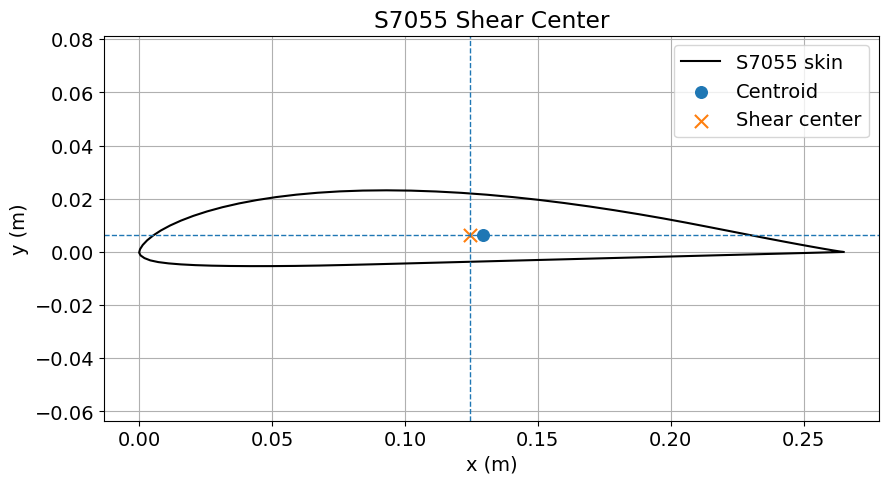

In [25]:

# ---------------------------------------------------------------------
# 9. PLOT
# ---------------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(x, y, '-k', label='S7055 skin')
plt.scatter(x_bar, y_bar, s=70, label='Centroid')
plt.scatter(x_sc_LE, y_bar, s=90, marker='x', label='Shear center')

plt.axhline(y_bar, linestyle='--', linewidth=1)
plt.axvline(x_sc_LE, linestyle='--', linewidth=1)

plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('S7055 Shear Center')
plt.grid()
plt.legend()
plt.show()


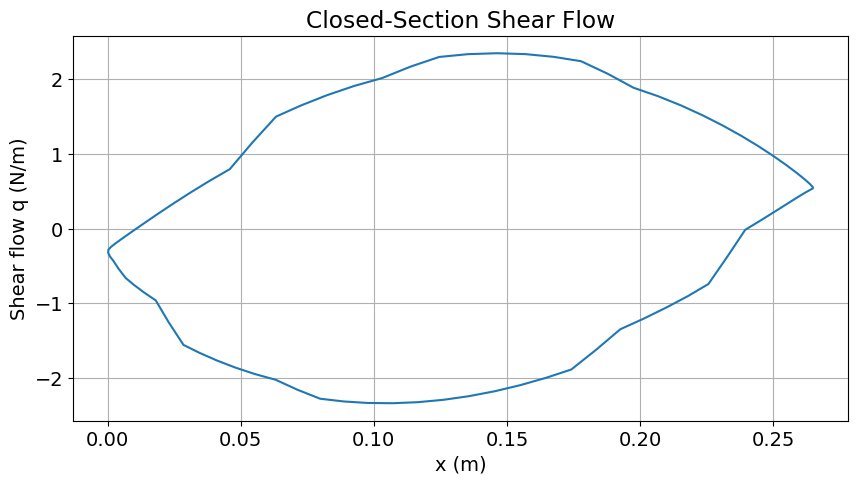

In [26]:

# ---------------------------------------------------------------------
# 10. SHEAR-FLOW PLOT
# ---------------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(x_mid, q_panel, '-')
plt.xlabel('x (m)')
plt.ylabel('Shear flow q (N/m)')
plt.title('Closed-Section Shear Flow')
plt.grid()
plt.show()


In [27]:
shear_force_actual = -20 # till our spar position
Xref = 0.25
Cmref = -0.073
CL = 0.72
Xcp = Xref - Cmref/CL
print(f"Chordwise Position of Center of Pressure (from LE) = {Xcp:.2g}")


Chordwise Position of Center of Pressure (from LE) = 0.35


In [28]:
# ================================================================
# SHEAR FLOW DUE TO ACTUAL APPLIED SHEAR FORCE
# ================================================================

V = shear_force_actual

# Contribution from each boom
dq_b = (
    V / D
    * (
        Ixy * x_c
        - Ixx * y_c
    )
    * B_total
)

# Cumulative basic shear flow
q_b = np.zeros(len(B_total))

for i in range(1, len(B_total)):
    q_b[i] = q_b[i-1] + dq_b[i-1]

print(f"Maximum basic shear flow = {np.max(np.abs(q_b)):.4f} N/m")

Maximum basic shear flow = 57.7555 N/m


In [29]:
# ================================================================
# PANEL BASIC SHEAR FLOW
# ================================================================

q_b_panel = 0.5 * (
    q_b + np.roll(q_b, -1)
)

# ================================================================
# REDUNDANT CONSTANT SHEAR FLOW
# ================================================================

q_0 = -np.sum(q_b_panel * ds) / np.sum(ds)

print(f"Redundant shear flow q_0 = {q_0:.4f} N/m")

x_mid = 0.5 * (x + np.roll(x, -1))
y_mid = 0.5 * (y + np.roll(y, -1))

# ================================================================
# MEDIAN-LINE ENCLOSED AREA
# ================================================================

x_mid_next = np.roll(x_mid, -1)
y_mid_next = np.roll(y_mid, -1)

A_m = 0.5 * abs(
    np.sum(
        x_mid * y_mid_next
        - y_mid * x_mid_next
    )
)

print(f"Median-line enclosed area A_m = {A_m:.6e} m^2")

# Centre of pressure
Xcp = Xref - Cmref / CL
x_cp = Xcp * chord

# Moment of lift about centroid
M_cp = shear_force_actual * (x_cp - x_bar)

print(f"Xcp = {Xcp:.6f} c")
print(f"x_cp = {x_cp:.6e} m")
print(f"M_cp = {M_cp:.6e} Nm")

q_m = M_cp / (2 * A_m)

# ================================================================
# FINAL CLOSED-SECTION SHEAR FLOW
# ================================================================

q_final = q_b_panel + q_0 + q_m

print(f"Maximum final shear flow = {np.max(np.abs(q_final)):.4f} N/m")
print(f"Minimum final shear flow = {np.min(q_final):.4f} N/m")
print(f"Maximum final shear flow = {np.max(q_final):.4f} N/m")

Redundant shear flow q_0 = -10.8633 N/m
Median-line enclosed area A_m = 4.919877e-03 m^2
Xcp = 0.351389 c
x_cp = 9.311806e-02 m
M_cp = 7.221083e-01 Nm
Maximum final shear flow = 120.2277 N/m
Minimum final shear flow = 26.3926 N/m
Maximum final shear flow = 120.2277 N/m


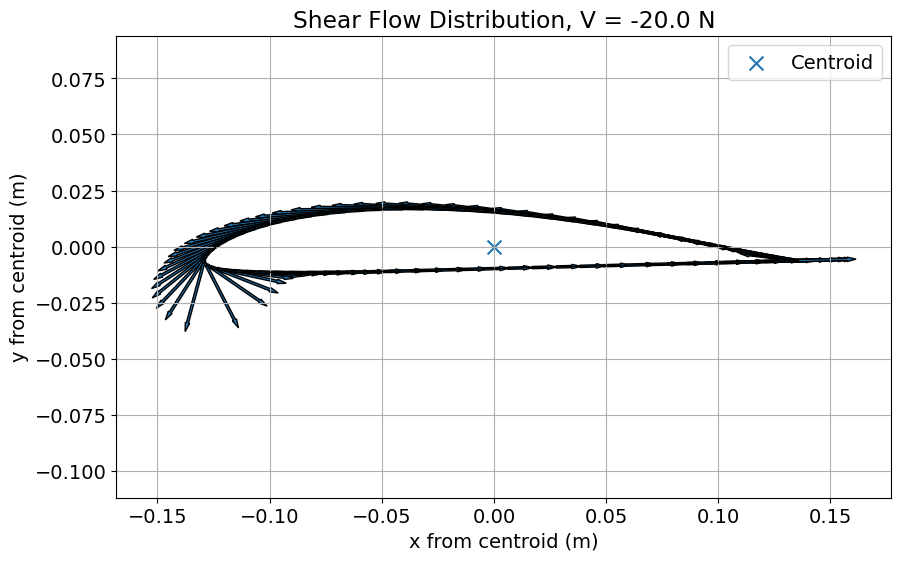

In [30]:
# ================================================================
# SHEAR FLOW PLOT
# ================================================================

x_panel = 0.5 * (
    x_c + np.roll(x_c, -1)
)

y_panel = 0.5 * (
    y_c + np.roll(y_c, -1)
)

plt.figure(figsize=(10, 6))

plt.plot(
    x_panel,
    y_panel,
    'k-',
    linewidth=1
)

# Scale arrows so they are visible
scale = 0.05 / np.max(np.abs(q_final))

for i in range(len(q_final)):

    dx_panel = np.roll(x_c, -1)[i] - x_c[i]
    dy_panel = np.roll(y_c, -1)[i] - y_c[i]

    length = np.hypot(dx_panel, dy_panel)

    # Unit tangent
    tx = dx_panel / length
    ty = dy_panel / length

    # Arrow direction follows sign of q
    arrow_length = q_final[i] * scale

    plt.arrow(
        x_panel[i],
        y_panel[i],
        tx * arrow_length,
        ty * arrow_length,
        head_width=0.002,
        head_length=0.004,
        length_includes_head=True
    )

plt.scatter(
    0,
    0,
    marker='x',
    s=100,
    label='Centroid'
)

plt.axis('equal')
plt.xlabel('x from centroid (m)')
plt.ylabel('y from centroid (m)')
plt.title(
    f'Shear Flow Distribution, V = {shear_force_actual:.1f} N'
)
plt.grid()
plt.legend()
plt.show()

In [31]:
# ================================================================
# TORQUE ABOUT CENTROID
# ================================================================

x_next = np.roll(x_c, -1)
y_next = np.roll(y_c, -1)

panel_moment_arm = (
    x_c * y_next
    - y_c * x_next
)

T_shear = np.sum(
    q_final * panel_moment_arm
)

print(f"Torque from shear flow = {T_shear:.6e} N m")

Torque from shear flow = 8.159716e-01 N m


In [32]:
# ================================================================
# SHEAR CENTER
# ================================================================

e = T_shear / shear_force_actual

print(f"Shear-center offset from centroid = {e:.6e} m")
print(f"Shear-center offset / chord = {e/chord:.6f}")

x_shear_center = x_bar + e

print(f"Shear center from LE = {x_shear_center:.6e} m")
print(f"Shear center x/c = {x_shear_center/chord:.6f}")

Shear-center offset from centroid = -4.079858e-02 m
Shear-center offset / chord = -0.153957
Shear center from LE = 8.842489e-02 m
Shear center x/c = 0.333679
